In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
train_path = "/content/drive/MyDrive/MRI photo/Training"
test_path = "/content/drive/MyDrive/MRI photo/Testing"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5634 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 147s 718ms/step - accuracy: 0.7309 - loss: 0.8699 - val_accuracy: 0.7975 - val_loss: 0.6062
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 112s 634ms/step - accuracy: 0.8303 - loss: 0.4548 - val_accuracy: 0.8419 - val_loss: 0.5274
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 107s 605ms/step - accuracy: 0.8458 - loss: 0.4122 - val_accuracy: 0.8138 - val_loss: 0.6237
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 108s 609ms/step - accuracy: 0.8408 - loss: 0.4134 - val_accuracy: 0.8413 - val_loss: 0.5462
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 110s 622ms/step - accuracy: 0.8237 - loss: 0.4465 - val_accuracy: 0.8081 - val_loss: 0.6784
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 113s 639ms/step - accuracy: 0.8568 - loss: 0.3769 - val_accuracy: 0.8719 - val_loss: 0.4756
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 112s 634ms/step - accuracy: 0.8600 - loss: 0.3625 - val_accuracy: 0.8344 - val_loss: 0.6104
Epoch 8/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 110s 622ms/step - accuracy: 0.8731 -

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
177/177 ━━━━━━━━━━━━━━━━━━━━ 121s 647ms/step - accuracy: 0.8868 - loss: 0.2854 - val_accuracy: 0.8825 - val_loss: 0.5052
Epoch 2/5
177/177 ━━━━━━━━━━━━━━━━━━━━ 111s 626ms/step - accuracy: 0.9002 - loss: 0.2502 - val_accuracy: 0.8500 - val_loss: 0.8098
Epoch 3/5
177/177 ━━━━━━━━━━━━━━━━━━━━ 110s 619ms/step - accuracy: 0.9125 - loss: 0.2213 - val_accuracy: 0.8794 - val_loss: 0.7269
Epoch 4/5
177/177 ━━━━━━━━━━━━━━━━━━━━ 108s 608ms/step - accuracy: 0.9304 - loss: 0.1775 - val_accuracy: 0.9038 - val_loss: 0.5182
Epoch 5/5
177/177 ━━━━━━━━━━━━━━━━━━━━ 108s 612ms/step - accuracy: 0.9315 - loss: 0.1769 - val_accuracy: 0.9094 - val_loss: 0.5021


In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.9094 - loss: 0.5021
Test Accuracy: 0.909375011920929
Test Loss: 0.5020670890808105


In [ ]:
from sklearn.metrics import classification_report

test_data.reset()

pred = model.predict(test_data)

y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step
              precision    recall  f1-score   support

      glioma       0.95      0.77      0.85       400
  meningioma       0.86      0.88      0.87       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



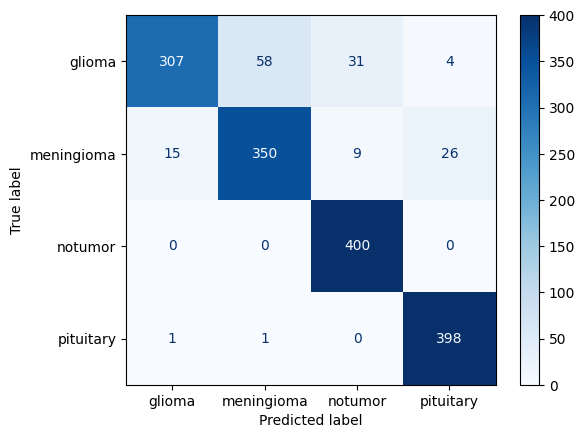

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_data.class_indices.keys())
)

disp.plot(cmap="Blues")
plt.show()

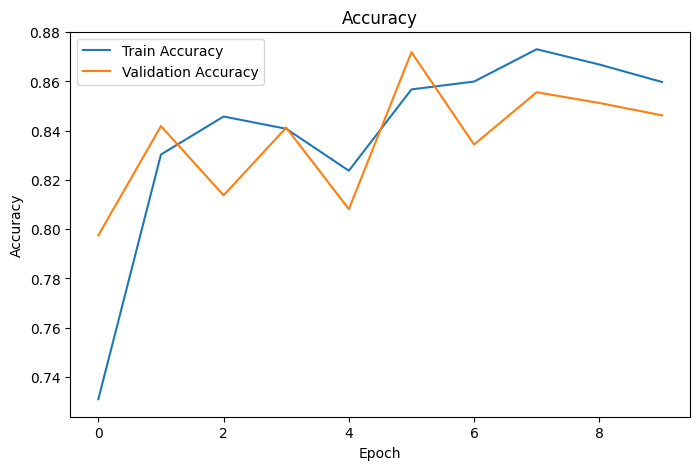

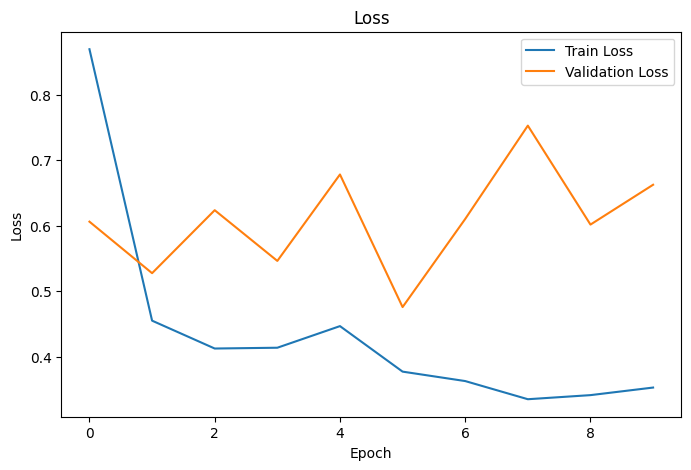

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.save("Brain_Tumor_VGG16.keras")

In [ ]:
model.save("/content/drive/MyDrive/Brain_Tumor_VGG16_FineTuned.keras")

In [ ]:
!pip install gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Brain_Tumor_VGG16_FineTuned.keras"
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Classes
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Prediction Function
def predict(image):
    image = image.resize((224,224))
    image = np.array(image)/255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image, verbose=0)

    predicted_class = classes[np.argmax(prediction)]
    confidence = float(np.max(prediction))*100

    return f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"

# Gradio Interface
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Textbox(label="Result"),
    title="🧠 Brain Tumor Detection using VGG16",
    description="Upload an MRI Image"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://32a0f7c11c116d2ca5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
